# codeBERT - ai detection

This notebook trains with codeBERT and a set of dataset [include bibliography] for ai detection

The model implemented is `codeBERT`.
For a better performance, the training process was made on Google Colab and the trained model was downloaded

This program:
 
* Prepares environment for Google Colab training
1. Load dataframes
2. Separates attributes and labels.
3. Imports model.
4. Compiles model
5. Tokenizes dataframes
6. Trains the model. **(+12h CPU & ≈2,5h GPU)**
* Downloads model to add it to local repository
7. Loads the trained model
8. Runs validation
9. Evaluates Train vs validation **(≈1h CPU & ≈10min GPU)**
10. Plots train vs validation behavior (accuracy & loss).
11. Makes predictions for test. **(≈X CPU & ≈1min GPU)**
12. Evaluates Test
13. Plots confusion Matrix.

## *Preparación para ejecutar training en Google Colab

Para correr el training desde la GPU de Google colab descomentar las siguientes celdas de código.

Así como cambiar el tipo de entorno de ejecución a GPU:
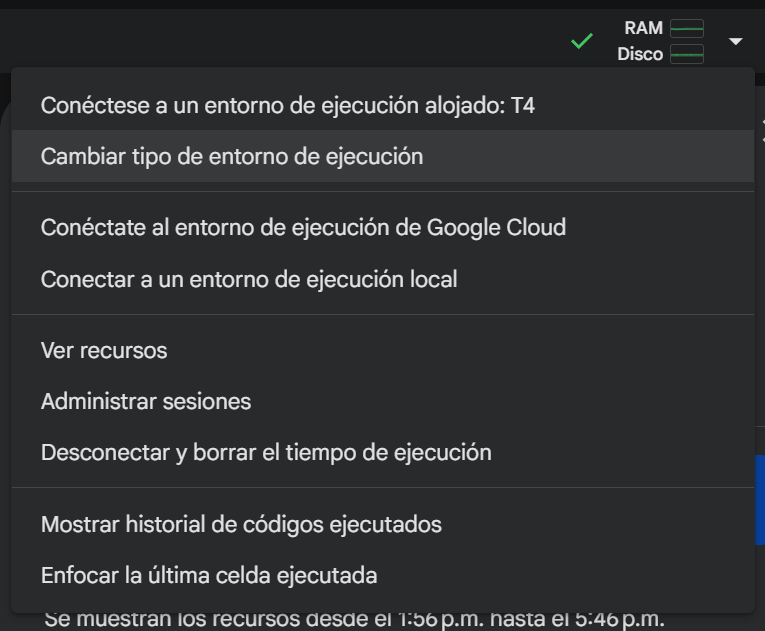
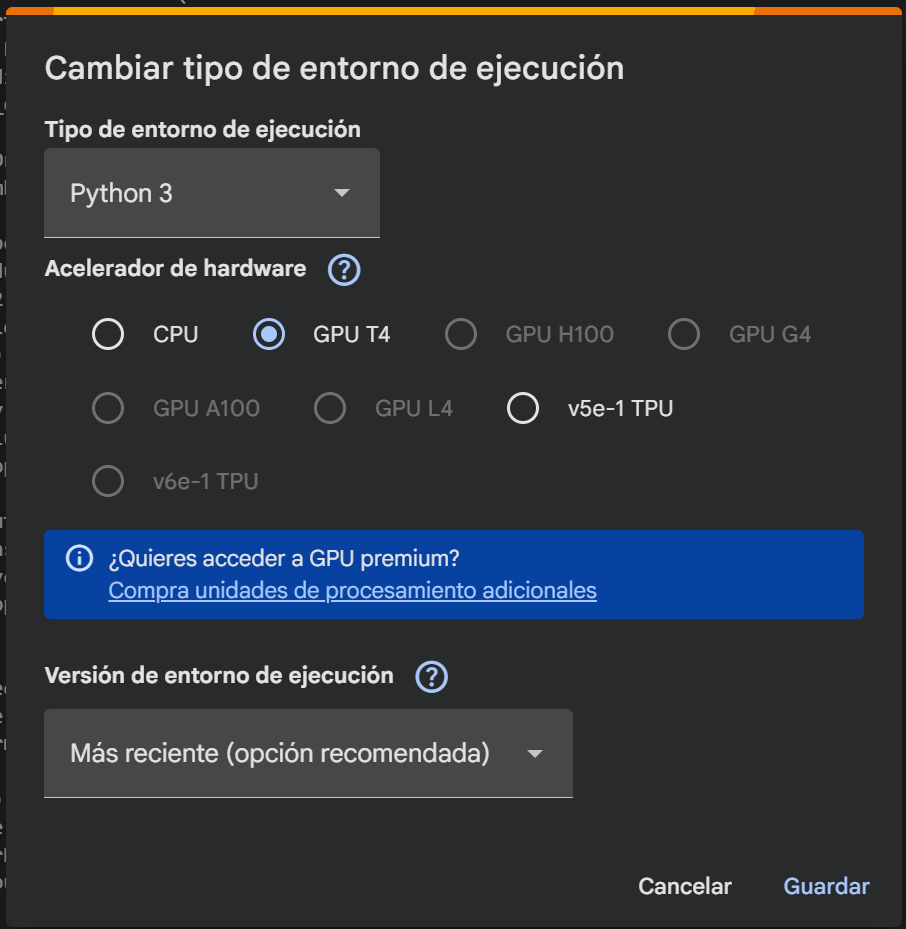

Este entorno de ejecución tiene un límite diario por lo que al finalizar el entrenamiento se recomienda guardar los resultados del mismo.

In [ ]:
# !git clone https://github.com/paustelito/ai-code-analyzer.git

Cloning into 'ai-code-analyzer'...
remote: Enumerating objects: 11322, done.
remote: Counting objects: 100% (42/42), done.
remote: Compressing objects: 100% (32/32), done.
remote: Total 11322 (delta 9), reused 28 (delta 8), pack-reused 11280 (from 2)
Receiving objects: 100% (11322/11322), 28.59 MiB | 12.89 MiB/s, done.
Resolving deltas: 100% (2996/2996), done.


In [ ]:
# %cd ai-code-analyzer

/content/ai-code-analyzer


In [ ]:
# !git checkout feat/codeBERT

Updating files: 100% (9620/9620), done.
Branch 'feat/codeBERT' set up to track remote branch 'feat/codeBERT' from 'origin'.
Switched to a new branch 'feat/codeBERT'


In [ ]:
# %cd Training

/content/ai-code-analyzer/Training


## Imports

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os
import torch
import json
import torch
import importlib

from tqdm import tqdm

from transformers import AutoTokenizer, AutoModel

from pathlib import Path

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import tensorflow as tf

## 1. Load dataframes

In [7]:
ai_train = pd.read_csv("../Dataframes/df_ai/df_ai_train.csv")
ai_val = pd.read_csv("../Dataframes/df_ai/df_ai_val.csv")
ai_test = pd.read_csv("../Dataframes/df_ai/df_ai_test.csv")

plagiarism_train = pd.read_csv("../Dataframes/df_plagiarism/df_plagiarism_train.csv")
plagiarism_val = pd.read_csv("../Dataframes/df_plagiarism/df_plagiarism_val.csv")
plagiarism_test = pd.read_csv("../Dataframes/df_plagiarism/df_plagiarism_test.csv")

print("------AI shapes------")
print("Train: ", ai_train.shape)
print("Validation: ", ai_val.shape)
print("Test: ", ai_test.shape)
print("------Plagiarism shapes------")
print("Train: ", plagiarism_train.shape)
print("Validation: ", plagiarism_val.shape)
print("Test: ", plagiarism_test.shape)

ai_train.head()

------AI shapes------
Train:  (24000, 20)
Validation:  (3000, 20)
Test:  (3000, 20)
------Plagiarism shapes------
Train:  (24000, 56)
Validation:  (3000, 56)
Test:  (3000, 56)


,code,label,approx_tokens,comment_density,avg_line_length,line_length_variance,blank_line_ratio,num_classes,num_methods,num_if,num_for,num_while,num_switch,o_complexity,max_depth,total_nodes,num_literals,num_ids,unique_ids,id_diversity
0,private Set<Integer> perNodeRelease(final C th...,0,101,0.0,61.882353,1268.339100,0.055556,0.0,0.0,0.0,0.0,0.0,0.0,1.0,6.0,0.0,0.0,63.0,30.0,0.476190
1,@Override\n public AuthenticationStatus for...,0,23,0.0,34.777778,702.395062,0.100000,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,19.0,15.0,0.789474
2,public void callWorkListenerWithError(WorkCont...,1,28,0.0,49.500000,2072.250000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,1.0,5.0,0.0,0.0,7.0,7.0,1.000000
3,public void setSubscription(Subscription s) {\...,1,14,0.0,33.250000,500.187500,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,6.0,5.0,0.833333
4,public boolean getDialogContentInset(int theme...,1,20,0.0,44.666667,1461.222222,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,21.0,16.0,0.761905


## 2. Separate attribites and labels

In [8]:
X_ai_train = ai_train.drop("label", axis=1)
y_ai_train = ai_train["label"]

X_ai_val = ai_val.drop("label", axis=1)
y_ai_val = ai_val["label"]

X_ai_test = ai_test.drop("label", axis=1)
y_ai_test = ai_test["label"]

X_plagiarism_train = plagiarism_train.drop("label", axis=1)
y_plagiarism_train = plagiarism_train["label"]

X_plagiarism_val = plagiarism_val.drop("label", axis=1)
y_plagiarism_val = plagiarism_val["label"]

X_plagiarism_test = plagiarism_test.drop("label", axis=1)
y_plagiarism_test = plagiarism_test["label"]


print("X_ai_train:", X_ai_train.shape)
print("y_ai_train:", y_ai_train.shape)
print("X_ai_val:", X_ai_val.shape)
print("y_ai_val:", y_ai_val.shape)
print("X_ai_test:", X_ai_test.shape)
print("y_ai_test:", y_ai_test.shape)

print("X_plagiarism_train:", X_plagiarism_train.shape)
print("y_plagiarism_train:", y_plagiarism_train.shape)
print("X_plagiarism_val:", X_plagiarism_val.shape)
print("y_plagiarism_val:", y_plagiarism_val.shape)
print("X_plagiarism_test:", X_plagiarism_test.shape)
print("y_plagiarism_test:", y_plagiarism_test.shape)

print("\nTraining class distribution:")
print(y_ai_train.value_counts().sort_index())
print("\nValidation class distribution:")
print(y_ai_val.value_counts().sort_index())
print("\nTesting class distribution:")
print(y_ai_test.value_counts().sort_index())

print("\nTraining class distribution:")
print(y_plagiarism_train.value_counts().sort_index())
print("\nValidation class distribution:")
print(y_plagiarism_val.value_counts().sort_index())
print("\nTesting class distribution:")
print(y_plagiarism_test.value_counts().sort_index())


X_ai_train: (24000, 19)
y_ai_train: (24000,)
X_ai_val: (3000, 19)
y_ai_val: (3000,)
X_ai_test: (3000, 19)
y_ai_test: (3000,)
X_plagiarism_train: (24000, 55)
y_plagiarism_train: (24000,)
X_plagiarism_val: (3000, 55)
y_plagiarism_val: (3000,)
X_plagiarism_test: (3000, 55)
y_plagiarism_test: (3000,)

Training class distribution:
label
0    12000
1    12000
Name: count, dtype: int64

Validation class distribution:
label
0    1500
1    1500
Name: count, dtype: int64

Testing class distribution:
label
0    1500
1    1500
Name: count, dtype: int64

Training class distribution:
label
0    12000
1    12000
Name: count, dtype: int64

Validation class distribution:
label
0    1500
1    1500
Name: count, dtype: int64

Testing class distribution:
label
0    1500
1    1500
Name: count, dtype: int64


## 3. Import model

In [9]:
sys.path.append(os.path.abspath("../Dataset/conplag_version_2/"))

from scripts.codebert import create_model

tokenizer, model = create_model()

print(type(model))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/498 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: microsoft/codebert-base
Key                        | Status     | 
---------------------------+------------+-
pooler.dense.bias          | UNEXPECTED | 
pooler.dense.weight        | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


<class 'transformers.models.roberta.modeling_roberta.RobertaForSequenceClassification'>


## 4. Compile model

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=2e-5
)

print(device)

cuda


In [11]:
print(model)

RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

## 5. Tokenizing

In [12]:
from torch.utils.data import Dataset, DataLoader

# Classes and methods to tokenize dataframes

class CodeAiDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length=512):
        self.codes = dataframe["code"].tolist()
        self.labels = dataframe["label"].tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.codes)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.codes[idx],
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[idx]).long()
        }

class CodePlagiarismDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length=512):
        self.code1 = dataframe["code1"].tolist()
        self.code2 = dataframe["code2"].tolist()
        self.labels = dataframe["label"].tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.code1[idx],
            self.code2[idx],
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[idx]).long()
        }

In [13]:
ai_train_tokenized = CodeAiDataset(ai_train, tokenizer)
ai_val_tokenized = CodeAiDataset(ai_val, tokenizer)
ai_test_tokenized = CodeAiDataset(ai_test, tokenizer)

plagiarism_train_tokenized = CodePlagiarismDataset(plagiarism_train, tokenizer)
plagiarism_val_tokenized = CodePlagiarismDataset(plagiarism_val, tokenizer)
plagiarism_test_tokenized = CodePlagiarismDataset(plagiarism_test, tokenizer)

ai_train_loader = DataLoader(
    ai_train_tokenized,
    batch_size=8,
    shuffle=True
)

ai_val_loader = DataLoader(
    ai_val_tokenized,
    batch_size=8,
    shuffle=True
)

ai_test_loader = DataLoader(
    ai_test_tokenized,
    batch_size=8,
    shuffle=False
)

plagiarism_train_loader = DataLoader(
    plagiarism_train_tokenized,
    batch_size=8,
    shuffle=True
)

plagiarism_val_loader = DataLoader(
    plagiarism_val_tokenized,
    batch_size=8,
    shuffle=True
)

plagiarism_test_loader = DataLoader(
    plagiarism_test_tokenized,
    batch_size=8,
    shuffle=False
)

## 6. Training

In [ ]:
# Training with ai_train dataframe

epochs = 3

train_losses = []
train_accuracies = []

for epoch in range(epochs):
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for batch in tqdm(ai_train_loader):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        logits = outputs.logits

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        predictions = torch.argmax(logits, dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    epoch_loss = total_loss / len(ai_train_loader)
    epoch_accuracy = correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    print(f"Epoch {epoch + 1}/{epochs}")
    print(f"Train Loss: {epoch_loss:.4f}")
    print(f"Train Accuracy: {epoch_accuracy:.4f}")

100%|██████████| 3000/3000 [38:38<00:00,  1.29it/s]


Epoch 1/3
Train Loss: 0.0340
Train Accuracy: 0.9894


100%|██████████| 3000/3000 [38:41<00:00,  1.29it/s]


Epoch 2/3
Train Loss: 0.0143
Train Accuracy: 0.9953


100%|██████████| 3000/3000 [38:41<00:00,  1.29it/s]

Epoch 3/3
Train Loss: 0.0075
Train Accuracy: 0.9980


## *Downloading model and add it to local repository

For saving the model trained in Google colab use the followed commented code

In [ ]:
# %cd /content/ai-code-analyzer

/content/ai-code-analyzer


In [ ]:
# !mkdir -p models/codebert_ai_detector

In [ ]:
# model.save_pretrained("models/codebert_ai_detector")
# tokenizer.save_pretrained("models/codebert_ai_detector")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('models/codebert_ai_detector/tokenizer_config.json',
 'models/codebert_ai_detector/tokenizer.json')

In [ ]:
# !ls models/codebert_ai_detector

config.json  model.safetensors	tokenizer_config.json  tokenizer.json


In [ ]:
# !zip -r codebert_model.zip /content/ai-code-analyzer/models/codebert_ai_detector

  adding: content/ai-code-analyzer/models/codebert_ai_detector/ (stored 0%)
  adding: content/ai-code-analyzer/models/codebert_ai_detector/tokenizer.json (deflated 82%)
  adding: content/ai-code-analyzer/models/codebert_ai_detector/tokenizer_config.json (deflated 51%)
  adding: content/ai-code-analyzer/models/codebert_ai_detector/model.safetensors (deflated 7%)
  adding: content/ai-code-analyzer/models/codebert_ai_detector/config.json (deflated 51%)


In [ ]:
# !ls -lh codebert_model.zip

-rw-r--r-- 1 root root 443M Jun  8 22:18 codebert_model.zip


### Important
Add the dowloadad folder content codebert_ai_detector to de local repository for saving changes

## 7. Load the trained model

In [36]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

model_path = "models/codebert_ai_detector"

tokenizer = AutoTokenizer.from_pretrained(model_path)

model = AutoModelForSequenceClassification.from_pretrained(
    model_path
)

model.to(device)
model.eval()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

## 8. Validation

In [49]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

all_predictions = []
all_labels = []

model.eval()

total_val_loss = 0
val_correct = 0
val_total = 0

with torch.no_grad():

    for batch in tqdm(ai_val_loader):

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        logits = outputs.logits

        total_val_loss += loss.item()

        predictions = torch.argmax(
            logits,
            dim=1
        )

        val_correct += (
            predictions == labels
        ).sum().item()

        val_total += labels.size(0)

val_loss = total_val_loss / len(ai_val_loader)
val_accuracy = val_correct / val_total

print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_accuracy)

100%|██████████| 375/375 [01:21<00:00,  4.61it/s]

Validation Loss: 0.0153577007233204
Validation Accuracy: 0.9966666666666667


## 9. Train & validation evaluation (metrics)

In [52]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(model, data_loader, device):
    all_predictions = []
    all_labels = []

    model.eval()

    with torch.no_grad():
        for batch in tqdm(data_loader):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            predictions = torch.argmax(outputs.logits, dim=1)

            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_predictions)
    precision = precision_score(all_labels, all_predictions, average="weighted")
    recall = recall_score(all_labels, all_predictions, average="weighted")
    f1 = f1_score(all_labels, all_predictions, average="weighted")

    return accuracy, precision, recall, f1

In [53]:
train_accuracy, train_precision, train_recall, train_f1 = evaluate_model(
    model,
    ai_train_loader,
    device
)

val_accuracy, val_precision, val_recall, val_f1 = evaluate_model(
    model,
    ai_val_loader,
    device
)

100%|██████████| 375/375 [01:23<00:00,  4.47it/s]


In [55]:
print("Training Results")
print("---------------------")
print(f"Accuracy : {train_accuracy:.4f}")
print(f"Precision: {train_precision:.4f}")
print(f"Recall   : {train_recall:.4f}")
print(f"F1 Score : {train_f1:.4f}")

print("\nValidation Results")
print("---------------------")
print(f"Accuracy : {val_accuracy:.4f}")
print(f"Precision: {val_precision:.4f}")
print(f"Recall   : {val_recall:.4f}")
print(f"F1 Score : {val_f1:.4f}")

Training Results
---------------------
Accuracy : 0.9990
Precision: 0.9990
Recall   : 0.9990
F1 Score : 0.9990

Validation Results
---------------------
Accuracy : 0.9967
Precision: 0.9967
Recall   : 0.9967
F1 Score : 0.9967


## 10. Training vs Validation behavior plots

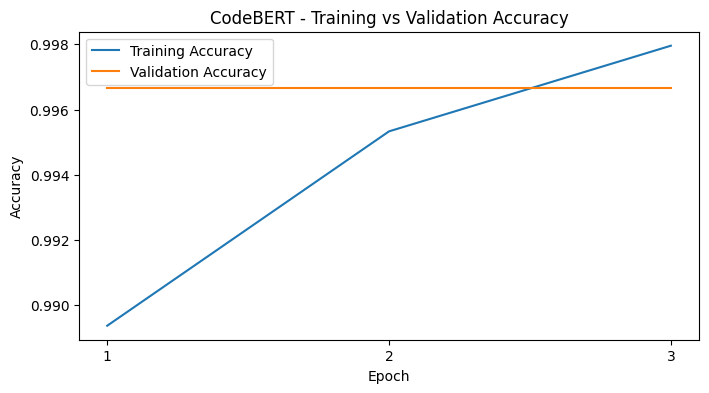

In [62]:
import matplotlib.pyplot as plt

epochs = [1, 2, 3]

plt.figure(figsize=(8,4))

plt.plot(
    epochs,
    train_accuracies,
    label="Training Accuracy"
)

plt.plot(
    epochs,
    [val_accuracy] * len(epochs),
    label="Validation Accuracy"
)

plt.title(
    "CodeBERT - Training vs Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.xticks(epochs)

plt.legend()

plt.show()

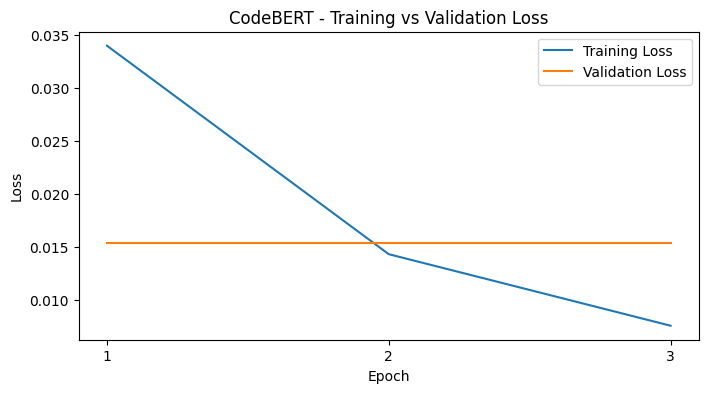

In [63]:
plt.figure(figsize=(8,4))

plt.plot(
    epochs,
    train_losses,
    label="Training Loss"
)

plt.plot(
    epochs,
    [val_loss] * len(epochs),
    label="Validation Loss"
)

plt.title(
    "CodeBERT - Training vs Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.xticks(epochs)

plt.legend()

plt.show()

## 11. Predictions

In [64]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

test_predictions = []
test_labels = []

model.eval()

with torch.no_grad():

    for batch in tqdm(ai_test_loader):

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        logits = outputs.logits

        predictions = torch.argmax(
            logits,
            dim=1
        )

        test_predictions.extend(
            predictions.cpu().numpy()
        )

        test_labels.extend(
            labels.cpu().numpy()
        )

100%|██████████| 375/375 [01:24<00:00,  4.41it/s]


## 12. Test evaluation (metrics)

In [65]:
test_accuracy = accuracy_score(
    test_labels,
    test_predictions
)

test_precision = precision_score(
    test_labels,
    test_predictions,
    average="weighted",
    zero_division=0
)

test_recall = recall_score(
    test_labels,
    test_predictions,
    average="weighted",
    zero_division=0
)

test_f1 = f1_score(
    test_labels,
    test_predictions,
    average="weighted",
    zero_division=0
)

print("Test Results")
print("---------------------")
print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1 Score : {test_f1:.4f}")

Test Results
---------------------
Accuracy : 0.9983
Precision: 0.9983
Recall   : 0.9983
F1 Score : 0.9983


## 13. Confussion Matrix

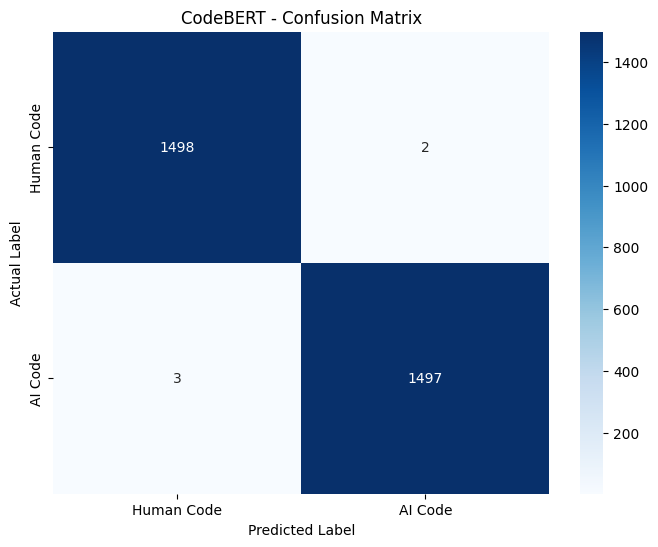

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    test_labels,
    test_predictions
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Human Code", "AI Code"],
    yticklabels=["Human Code", "AI Code"]
)

plt.title("CodeBERT - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()